In [1]:
# Cell 1: Setup
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
import numpy as np

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.family"] = "DejaVu Sans"

with open("../backend/seed_jobs.json", "r", encoding="utf-8") as f:
    jobs = json.load(f)

df = pd.DataFrame(jobs)
print(f"Loaded {len(df)} jobs")
print(df.columns.tolist())
df.head(3)

Loaded 30 jobs
['title', 'company', 'location', 'description', 'required_skills']


,title,company,location,description,required_skills
0,AWS Cloud Architect (W2 Only),iPivot,"New York, NY",Role: AWS Cloud ArchitectLocation: NYC NY3 Day...,"[Python, Docker, AWS, Linux, Leadership]"
1,Azure Cloud Engineer,Scion Staffing,"Oakland, CA",Scion Technology has been engaged to conduct a...,"[Python, AWS, Linux, Leadership]"
2,"Business Controlling, Full Value Chain Americas",SKF Group,"Blue Bell, PA",Business Controlling\n\nFull Value Chain Ameri...,"[Communication, Leadership]"


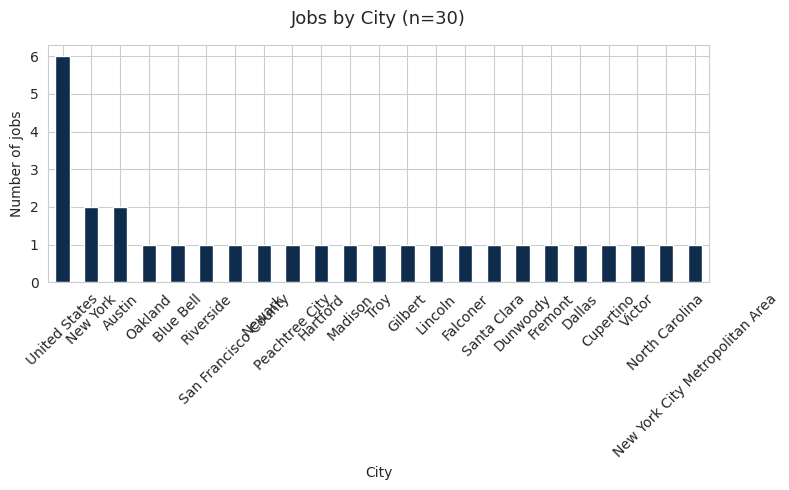

city
United States                      6
New York                           2
Austin                             2
Oakland                            1
Blue Bell                          1
Riverside                          1
San Francisco County               1
Newark                             1
Peachtree City                     1
Hartford                           1
Madison                            1
Troy                               1
Gilbert                            1
Lincoln                            1
Falconer                           1
Santa Clara                        1
Dunwoody                           1
Fremont                            1
Dallas                             1
Cupertino                          1
Victor                             1
North Carolina                     1
New York City Metropolitan Area    1
Name: count, dtype: int64


In [2]:
# Cell 2: Chart 1 — Jobs by City
def extract_city(loc):
    if not loc:
        return "Unknown"
    return loc.split(",")[0].strip()

df["city"] = df["location"].apply(extract_city)
city_counts = df["city"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
city_counts.plot(kind="bar", color="#0F2C4D", ax=ax)
ax.set_title("Jobs by City (n=30)", fontsize=13, pad=15)
ax.set_xlabel("City")
ax.set_ylabel("Number of jobs")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("chart_1_jobs_by_city.png", bbox_inches="tight")
plt.show()
print(city_counts)

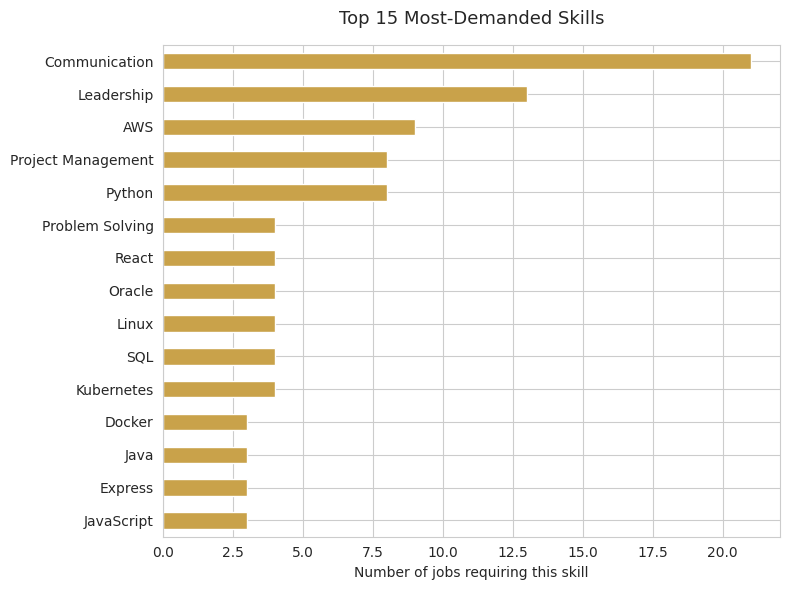

Communication         21
Leadership            13
AWS                    9
Python                 8
Project Management     8
Linux                  4
Kubernetes             4
SQL                    4
React                  4
Problem Solving        4
Oracle                 4
Docker                 3
JavaScript             3
Express                3
Java                   3
dtype: int64


In [3]:
# Cell 3: Chart 2 — Top 15 Demanded Skills
all_skills = [s for skills in df["required_skills"] for s in (skills if isinstance(skills, list) else skills.split())]
skill_counts = Counter(all_skills)
top_skills = pd.Series(dict(skill_counts.most_common(15)))

fig, ax = plt.subplots(figsize=(8, 6))
top_skills.sort_values().plot(kind="barh", color="#C9A24A", ax=ax)
ax.set_title("Top 15 Most-Demanded Skills", fontsize=13, pad=15)
ax.set_xlabel("Number of jobs requiring this skill")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("chart_2_top_skills.png", bbox_inches="tight")
plt.show()
print(top_skills)

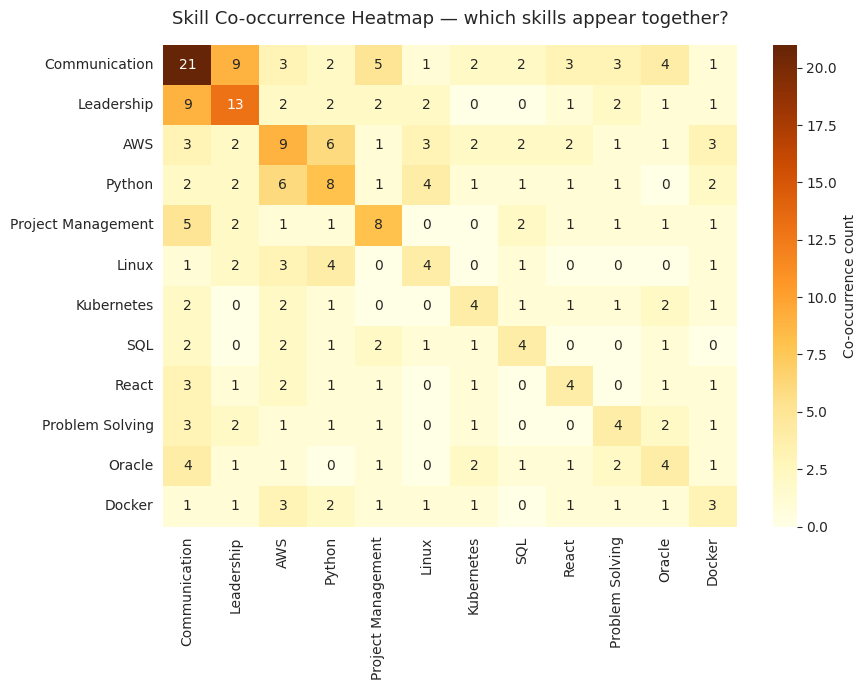

In [4]:
# Cell 4: Chart 3 — Skill Co-occurrence Heatmap
top_12 = [s for s, _ in skill_counts.most_common(12)]
matrix = pd.DataFrame(0, index=top_12, columns=top_12)

for skills in df["required_skills"]:
    skill_list = skills if isinstance(skills, list) else skills.split()
    relevant = [s for s in skill_list if s in top_12]
    for a, b in combinations(set(relevant), 2):
        matrix.at[a, b] += 1
        matrix.at[b, a] += 1
    for s in set(relevant):
        matrix.at[s, s] += 1

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matrix, annot=True, fmt="d", cmap="YlOrBr",
            cbar_kws={"label": "Co-occurrence count"}, ax=ax)
ax.set_title("Skill Co-occurrence Heatmap — which skills appear together?", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("chart_3_skill_cooccurrence.png", bbox_inches="tight")
plt.show()

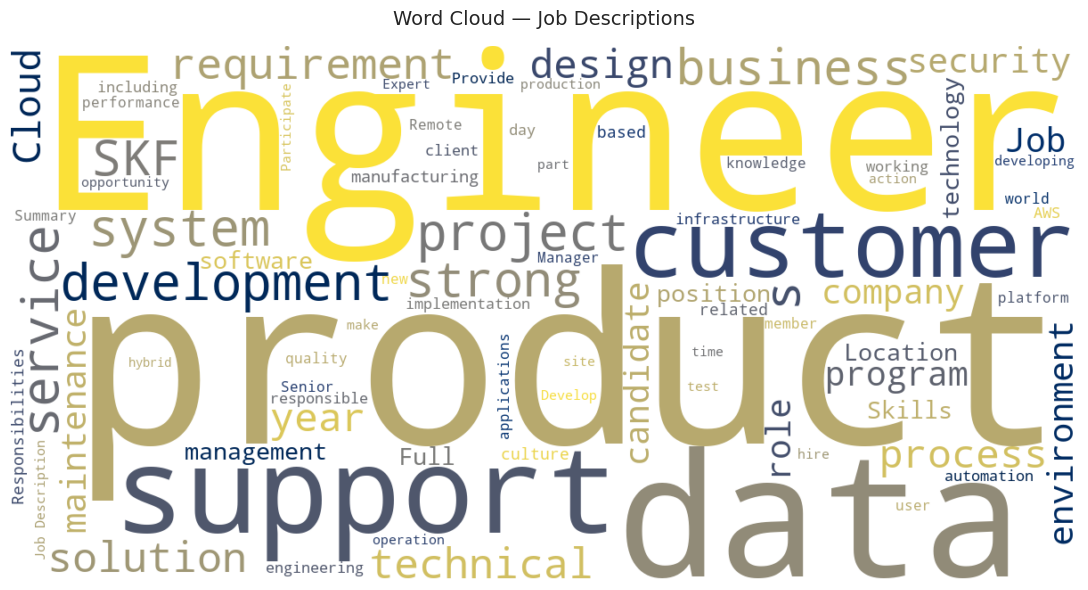

In [5]:
# Cell 5: Chart 4 — Word Cloud
from wordcloud import WordCloud, STOPWORDS

all_text = " ".join(df["description"].dropna())
stopwords = set(STOPWORDS)
stopwords.update(["work", "team", "experience", "looking", "join", "will", "able", "using", "use"])

wc = WordCloud(
    width=1200, height=600,
    background_color="white",
    colormap="cividis",
    stopwords=stopwords,
    max_words=80
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Job Descriptions", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("chart_4_wordcloud.png", bbox_inches="tight")
plt.show()